In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Analysis

In [2]:
data = pd.read_csv('data.csv')

print('dataset shape:', data.shape)
print('the columns names:\n', data.columns.tolist())


dataset shape: (569, 33)
the columns names:
 ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [3]:
print('missing values:\n',data.isnull().sum())

missing values:
 id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_wors

In [4]:
data = data.drop(['id', 'Unnamed: 32'], axis=1, errors='ignore')

target_column = 'diagnosis'
data[target_column] =  data[target_column].map({'M' : 1, 'B' : 0})

print('Distribution of the classes:\n',data[target_column].value_counts())

Distribution of the classes:
 diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
print('dataset info:\n', data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [6]:
print('describe:\n',data.describe())

describe:
         diagnosis  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  569.000000   569.000000    569.000000      569.000000   569.000000   
mean     0.372583    14.127292     19.289649       91.969033   654.889104   
std      0.483918     3.524049      4.301036       24.298981   351.914129   
min      0.000000     6.981000      9.710000       43.790000   143.500000   
25%      0.000000    11.700000     16.170000       75.170000   420.300000   
50%      0.000000    13.370000     18.840000       86.240000   551.100000   
75%      1.000000    15.780000     21.800000      104.100000   782.700000   
max      1.000000    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.07

In [7]:
X = data.drop(target_column, axis=1).values.astype(float)
y = data[target_column].values.astype(int)

In [ ]:
def train_test_split(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)

    test_count = int(test_size * len(X))

    test_indices = indices[:test_count] 
    train_indices = indices[test_count:]

    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
print(f'number of train samples: {len(X_train)}')
print(f'number of test samples: {len(X_test)}')

number of train samples: 456
number of test samples: 113


PURE KNN

In [ ]:
class KNN:
    def __init__(self, k=None):
        self.k = k

    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def euclidean_distance(self, x):
        return np.sqrt(np.sum((x - self.X_train) ** 2, axis=1))

    def predict(self, X_test):
        predictions = []
        
        for x in X_test:
            distances = self.euclidean_distance(x)
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train[k_indices]

            most_common = np.bincount(k_nearest_labels).argmax()
            predictions.append(most_common)

        return np.array(predictions)
    

def accuracy_score(y_true, y_pred):
        return np.sum(y_true == y_pred) / len(y_true)

Cross Validation

In [ ]:
def cross_validation(model, X, y, folds=5):
    fold_size = len(X) // folds
    scores = []

    indices = np.arange(len(X))
    np.random.shuffle(indices)

    for i in range(folds):
        start = i * fold_size
        end = (i+1)* fold_size
        validation_indices = indices[start:end]
        
        mask = np.ones(len(X), dtype=bool)
        mask[validation_indices] = False
        train_indices = indices[mask]

        X_cv_train, y_cv_train = X[train_indices], y[train_indices]
        X_cv_validation, y_cv_validation = X[validation_indices], y[validation_indices]

        model.fit(X_cv_train, y_cv_train)
        y_pred = model.predict(X_cv_validation)    

        accuracy = accuracy_score(y_cv_validation, y_pred)
        scores.append(accuracy)
    return np.mean(scores)

Search for the best K

In [13]:
def grid_search(X_train, y_train, k_range=range(1,17), folds=5):
    mean_accuracies = []
    
    for k in k_range:
        knn = KNN(k=k)
        cv_acc = cross_validation(knn, X_train, y_train, folds)
        mean_accuracies.append(cv_acc)
    
    best_k_index = np.argmax(mean_accuracies)
    best_k = k_range[best_k_index]
    best_accuracy = mean_accuracies[best_k_index]
    print(f"The Best K is {best_k} with accuracy {best_accuracy}")

    return best_k, best_accuracy, mean_accuracies


In [14]:
np.random.seed(42)
k_range = range(1,17)

best_k, best_accuracy, mean_accuracies = grid_search(X_train, y_train, k_range=k_range, folds=5)

The Best K is 1 with accuracy 0.9802197802197803


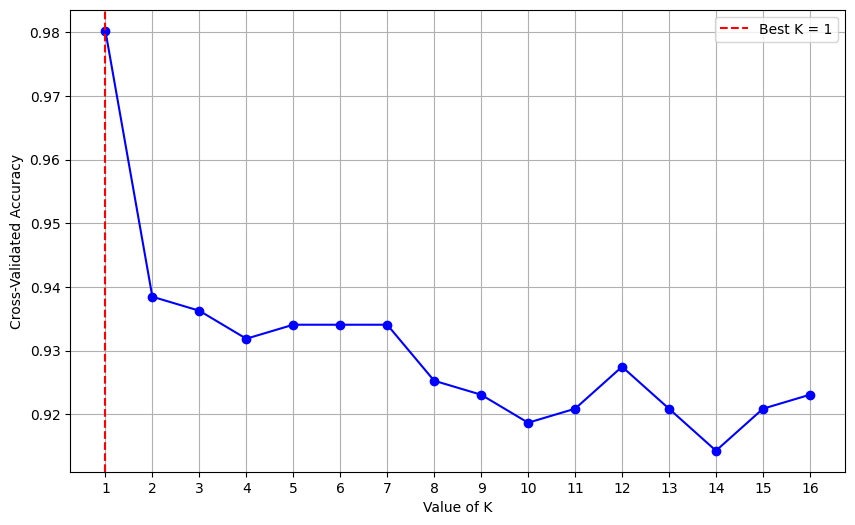

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_range, mean_accuracies, marker='o', linestyle='-', color='b')
plt.xlabel('Value of K')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Best K = {best_k}')
plt.legend()
plt.show()

KNN + Standard Scaler

In [16]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std = np.where(self.std == 0 , 1, self.std)

    def transform(self, X):
        X_scaled = (X - self.mean) / self.std
        return X_scaled

The correct way: fit only on train data

In [ ]:
scaler_correct = StandardScaler()
scaler_correct.fit(X_train)

X_train_scaled = scaler_correct.transform(X_train)
X_test_scaled = scaler_correct.transform(X_test)

knn_correct = KNN(k=best_k)
knn_correct.fit(X_train_scaled, y_train)
pred_correct = knn_correct.predict(X_test_scaled)
acc_correct = accuracy_score(y_test, pred_correct)

The wrong way: fit on the whole data:

In [18]:
X_all = np.concatenate((X_train, X_test), axis=0)
scaler_wrong = StandardScaler()
scaler_wrong.fit(X_all)

X_train_scaled_wrong = scaler_wrong.transform(X_train)
X_test_scaled_wrong = scaler_wrong.transform(X_test)

knn_wrong = KNN(k=best_k)
knn_wrong.fit(X_train_scaled_wrong ,y_train)
pred_wrong = knn_wrong.predict(X_test_scaled_wrong)
acc_wrong = accuracy_score(y_test, pred_wrong)

print(f"Accuracy (Correct Scaling): {acc_correct:.4f}")
print(f"Accuracy (With Data Leakage): {acc_wrong:.4f}")

Accuracy (Correct Scaling): 0.9381
Accuracy (With Data Leakage): 0.9381


In [19]:
mean_accuracies_scaled = []

for  k in k_range:
    knn = KNN(k=k)
    cv_acc = cross_validation(knn, X_train_scaled, y_train, folds=5)
    mean_accuracies_scaled.append(cv_acc)

best_k_index_scaled = np.argmax(mean_accuracies_scaled)
best_k_scaled = k_range[best_k_index_scaled]
best_accuracy_scaled = mean_accuracies_scaled[best_k_index_scaled]

print(f'the best k with scaling is {best_k_scaled} with accuracy: {best_accuracy_scaled}')


the best k with scaling is 1 with accuracy: 0.9868131868131869


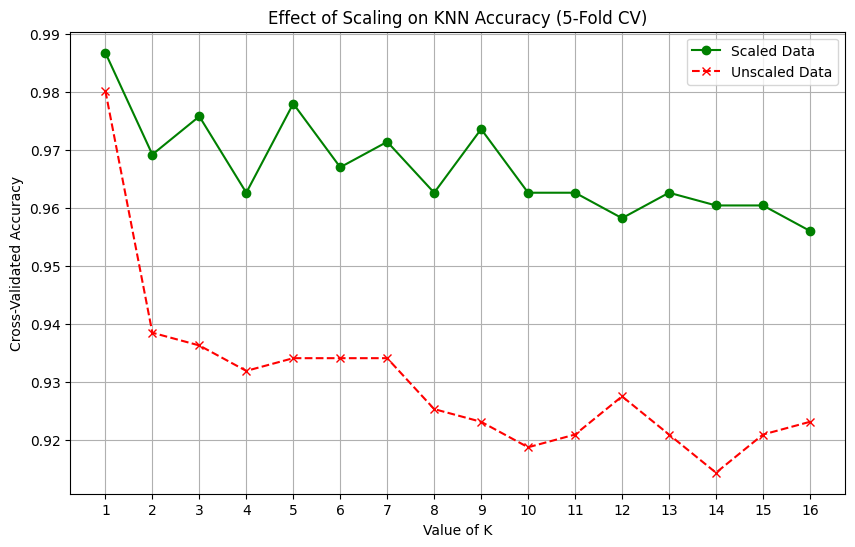

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(k_range, mean_accuracies_scaled, marker='o', linestyle='-', color='g', label='Scaled Data')

if 'mean_accuracies' in globals():
    plt.plot(k_range, mean_accuracies, marker='x', linestyle='--', color='r', label='Unscaled Data')

plt.title('Effect of Scaling on KNN Accuracy (5-Fold CV)')
plt.xlabel('Value of K')
plt.ylabel('Cross-Validated Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()


KNN + Feature Selection

In [21]:
def extract_feature_groups(data):
    features = data.drop('diagnosis', axis=1)

    mean_features = [col for col in features if col.endswith('_mean')]
    se_features = [col for col in features if col.endswith('_se')]
    worst_features = [col for col in features if col.endswith('_worst')]

    return features, mean_features, se_features, worst_features

features, mean_features, se_features, worst_features = extract_feature_groups(data)

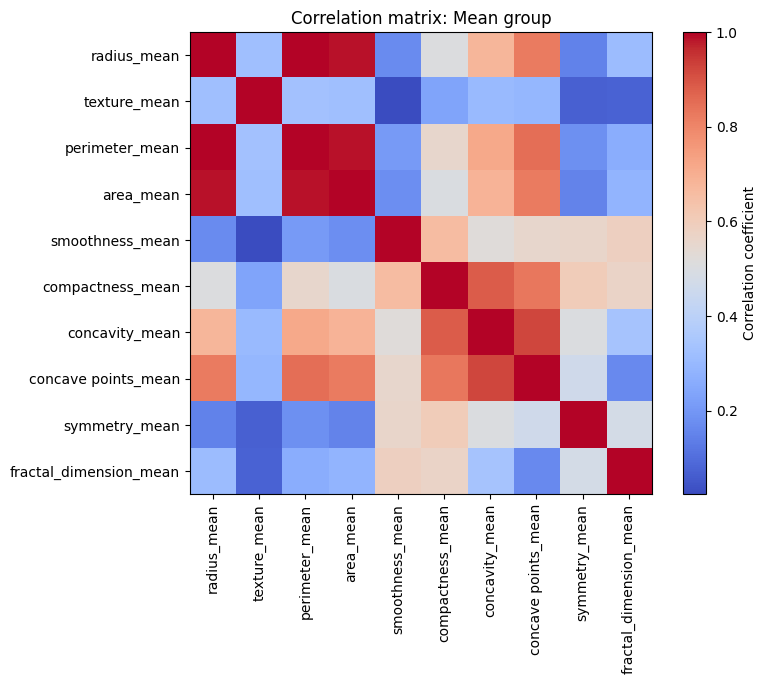

Mean group Analysis

features to drop with correlation > 0.9 are: ['concave points_mean', 'perimeter_mean', 'area_mean']


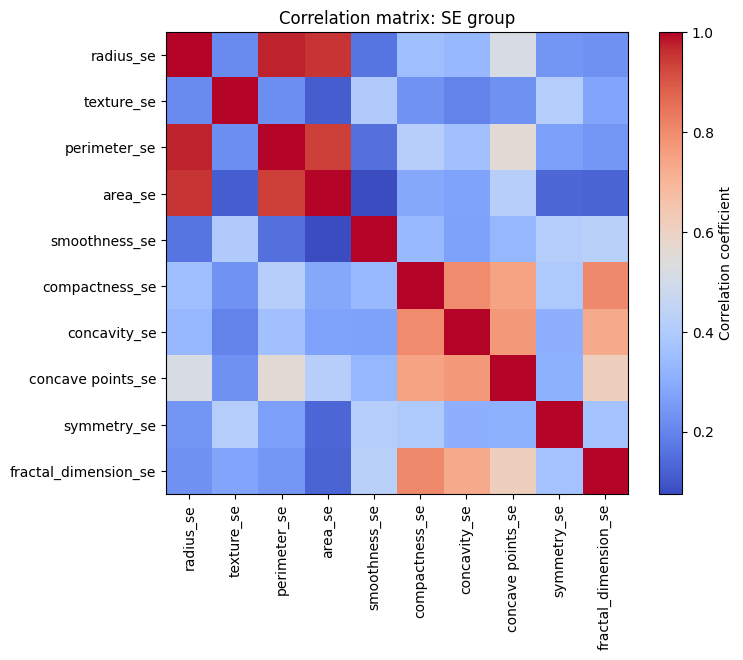

SE group Analysis

features to drop with correlation > 0.9 are: ['perimeter_se', 'area_se']


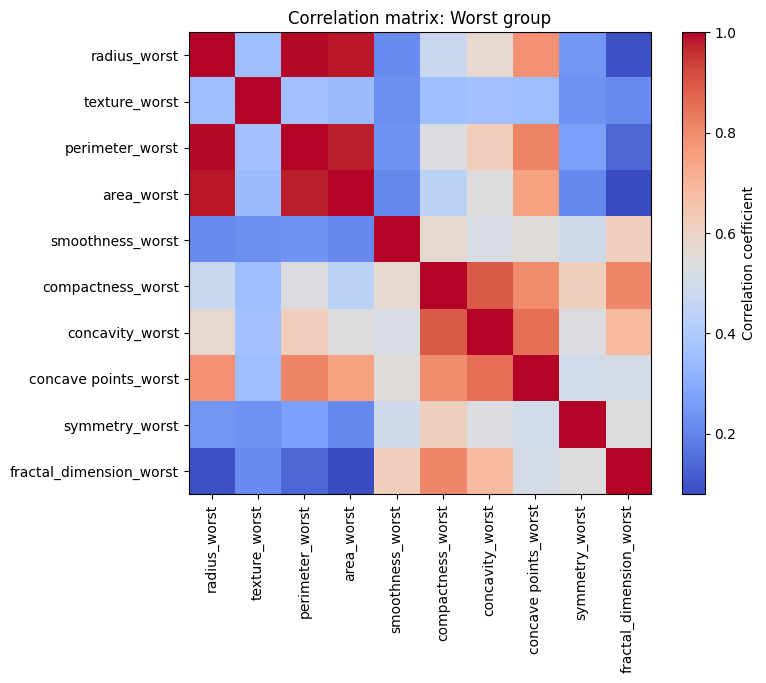

Worst group Analysis

features to drop with correlation > 0.9 are: ['perimeter_worst', 'area_worst']


In [22]:
def filter_features(df, group_name, threshold=0.9):
    corr_matrix  = df.corr().abs()

    plt.figure(figsize=(8,6))
    plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
    plt.colorbar(label='Correlation coefficient')
    plt.title(f'Correlation matrix: {group_name}')

    plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
    plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
    plt.show()


    to_drop = set()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i,j] > threshold:
                colname = corr_matrix.columns[i]
                to_drop.add(colname)

    print(f'{group_name} Analysis\n')
    print(f'features to drop with correlation > {threshold} are: {list(to_drop)}')

    selected_cols = [c for c in df.columns if c not in to_drop]
    return selected_cols


selected_mean = filter_features(features[mean_features], 'Mean group', threshold=0.9)
selected_se = filter_features(features[se_features], 'SE group', threshold=0.9)
selected_worst = filter_features(features[worst_features], 'Worst group', threshold=0.9)



In [23]:
final_features = selected_mean + selected_se + selected_worst
X_selected = features[final_features].values.astype(float)
y = data[target_column].values.astype(int)

In [24]:
X_train_selected, X_test_selected, y_train, y_test = train_test_split(X_selected, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train_selected)
X_train_selected_scaled = scaler.transform(X_train_selected)
X_test_selected_scaled =scaler.transform(X_test_selected)


best_k_selected, best_accuracy_selected, mean_accuracy_selected = grid_search(X_train_selected_scaled, y_train, k_range=k_range, folds=5)


knn_selected = KNN(k=best_k_selected)
knn_selected.fit(X_train_selected_scaled, y_train)
pred_selected = knn_selected.predict(X_test_selected_scaled)
accuracy_selected = accuracy_score(y_test, pred_selected)

print(f'Final Accuracy score with selected features is: {accuracy_selected}')


The Best K is 1 with accuracy 0.9978021978021978
Final Accuracy score with selected features is: 0.9292035398230089


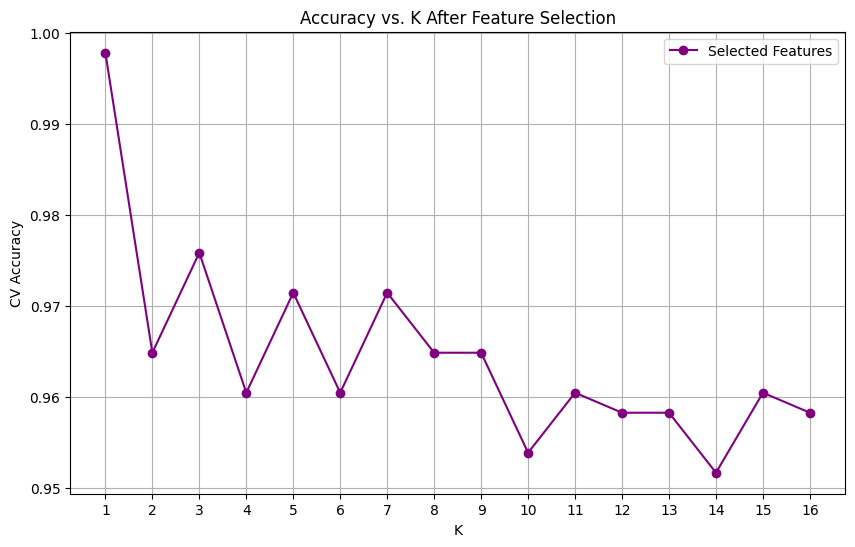

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, mean_accuracy_selected, marker='o', linestyle='-', color='purple', label='Selected Features')
plt.title('Accuracy vs. K After Feature Selection')
plt.xlabel('K')
plt.ylabel('CV Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.legend()
plt.show()

In [26]:
def calculate_metrics(y_true, y_pred):
    TP = np.sum((y_true==1) & (y_pred==1))
    TN = np.sum((y_true==0) & (y_pred==0))

    FP = np.sum((y_true==0) & (y_pred==1))
    FN = np.sum((y_true==1) & (y_pred==0))

    precision = TP / (TP + FP + 1e-10)
    recall = TP / (TP + FN + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

    print(f'Confusion Matrix: TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}')
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f'F1-Score: {f1}')


metrics = calculate_metrics(y_test, pred_selected)

Confusion Matrix: TP: 37, TN: 68, FP: 3, FN: 5
Precision: 0.9249999999976874
Recall: 0.8809523809502834
F1-Score: 0.9024390243380724


Robustness Test

In [ ]:
def inject_noise(X, y, noise_rate, seed=42):
    np.random.seed(seed)
    n_samples = len(X)

    X_noisy = X.copy()
    y_noisy = y.copy()

# label flipping
    n_flip = int(noise_rate*n_samples)
    flip_indices = np.random.choice(n_samples, n_flip, replace=False)

    y_noisy[flip_indices] = 1 - y_noisy[flip_indices]

# feature noise
    noise = np.random.normal(loc=0, scale=noise_rate, size=X.shape)
    X_noisy = X_noisy + noise
    
    return X_noisy, y_noisy, flip_indices

In [28]:
X_train_10, y_train_10, idx_10 = inject_noise(X_train_scaled, y_train, noise_rate=0.1)
X_train_20, y_train_20, idx_20 = inject_noise(X_train_scaled, y_train, noise_rate=0.2)

In [29]:
def check_distribution(y, name):
    counts = np.bincount(y)
    total = len(y)

    n_benign = counts[0] if len(counts) > 0 else 0
    n_malignant = counts[1] if len(counts) > 0 else 0
    
    ratio_b = (n_benign / total) * 100
    ratio_m = (n_malignant / total) * 100
    
    print(f'{name} : ')
    print(f'Benign ration = {ratio_b}')
    print(f'Malignant ration = {ratio_m}')

In [30]:
check_distribution(y_train, 'Clean Dataset')
check_distribution(y_train_10, '10% Noisy Dataset')
check_distribution(y_train_20, '20% noisy Dataset')

Clean Dataset : 
Benign ration = 62.71929824561403
Malignant ration = 37.280701754385966
10% Noisy Dataset : 
Benign ration = 59.86842105263158
Malignant ration = 40.131578947368425
20% noisy Dataset : 
Benign ration = 59.42982456140351
Malignant ration = 40.57017543859649


Sensitivity Check

In [31]:
k_values = sorted(list(set([1, best_k, 16]))) 
noise_levels = [0, 0.1, 0.2]
results = {k: [] for k in k_values}

datasets = [
    (X_train_scaled, y_train),
    (X_train_10, y_train_10),
    (X_train_20, y_train_20)
]

for noise_idx, (X_tr, y_tr) in enumerate(datasets):
    current_noise = noise_levels[noise_idx]
    print(f'noise level: {current_noise}')
    for k in k_values:
        knn = KNN(k=k)
        knn.fit(X_tr, y_tr)

        predictions = knn.predict(X_test_scaled)
        acc = accuracy_score(y_test, predictions)

        results[k].append(acc)
        print(f'k={k} : accuracy={acc}')

noise level: 0
k=1 : accuracy=0.9380530973451328
k=16 : accuracy=0.9469026548672567
noise level: 0.1
k=1 : accuracy=0.8407079646017699
k=16 : accuracy=0.9557522123893806
noise level: 0.2
k=1 : accuracy=0.7522123893805309
k=16 : accuracy=0.9469026548672567


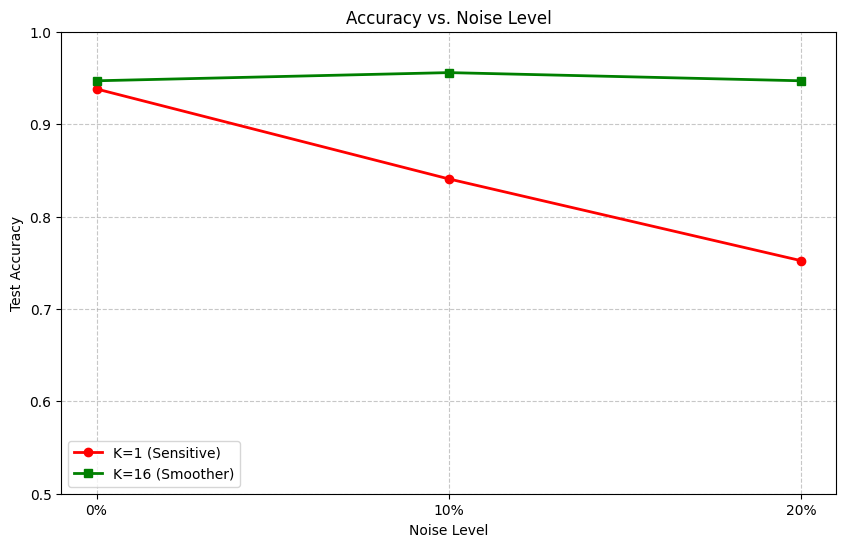

In [32]:
plt.figure(figsize=(10, 6))

markers = ['o', 's', '^']
colors = ['red', 'green', 'blue']

for i, k in enumerate(k_values):
    plt.plot(noise_levels, results[k], 
             marker=markers[i], 
             color=colors[i], 
             linewidth=2, 
             label=f'K={k} {"(Sensitive)" if k==1 else "(Smoother)"}')

plt.title('Accuracy vs. Noise Level')
plt.xlabel('Noise Level')
plt.ylabel('Test Accuracy')
plt.xticks(noise_levels, ['0%', '10%', '20%'])
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

Decision Boundaries

In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(ax, clf, X, y, title, h=0.5):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
    cmap_bold = ListedColormap(['#FF0000', '#0000FF'])
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.6)

    ax.scatter(X[:,0], X[:,1], c=y, cmap=cmap_bold, edgecolor='k', s=20)

    ax.set_title(title)
    ax.set_xlabel('Radius')
    ax.set_ylabel('Texture')

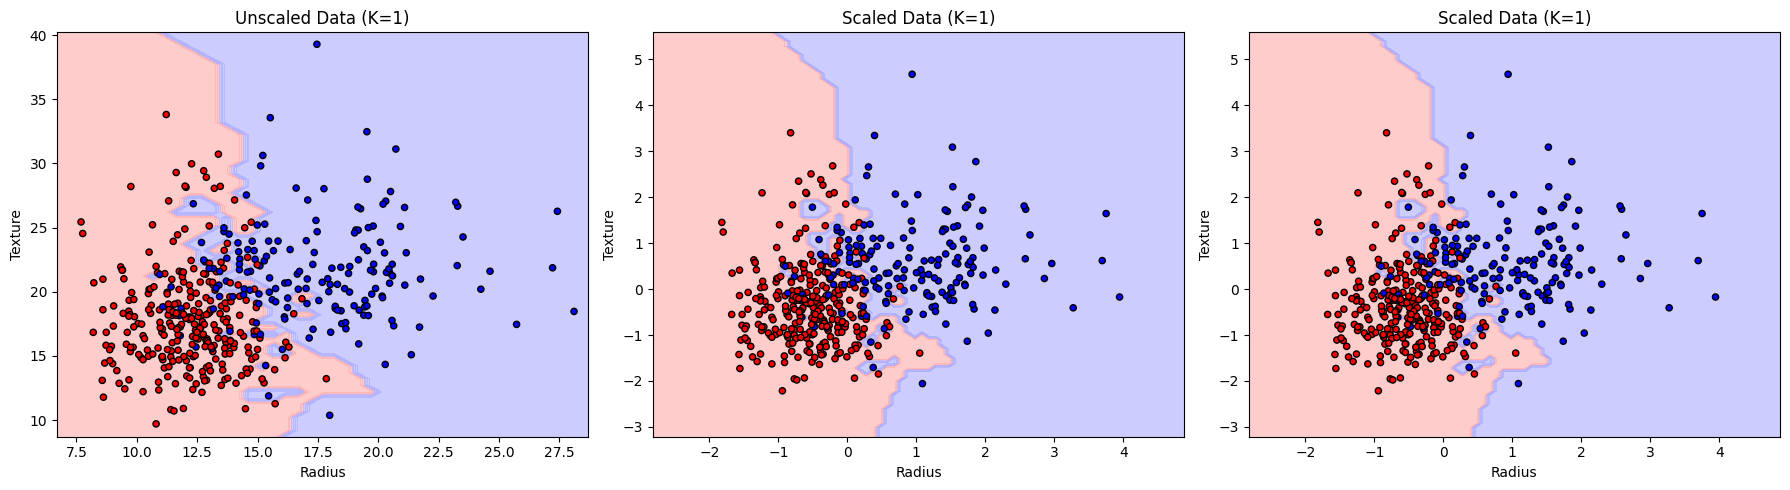

In [35]:
X_train_2d_unscaled = X_train[:,:2]
X_train_2d_scaled = X_train_scaled[:,:2]

knn_unscaled = KNN(k=best_k)
knn_unscaled.fit(X_train_2d_unscaled, y_train)

knn_scaled = KNN(k=best_k)
knn_scaled.fit(X_train_2d_scaled, y_train)

knn_k1 = KNN(k=1)
knn_k1.fit(X_train_2d_scaled, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


plot_decision_boundary(axes[0], knn_unscaled, X_train_2d_unscaled, y_train, 
                       f"Unscaled Data (K={best_k})", h=0.5)

plot_decision_boundary(axes[1], knn_scaled, X_train_2d_scaled, y_train, 
                       f"Scaled Data (K={best_k})", h=0.1)

plot_decision_boundary(axes[2], knn_k1, X_train_2d_scaled, y_train, 
                       f"Scaled Data (K=1)", h=0.1)

plt.tight_layout()
plt.show()

Which Distance Metric?

In [36]:
class KNN_Metric:
    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        if self.metric == 'euclidean':
            distances = np.linalg.norm(self.X_train - x, axis=1, ord=2)
            
        elif self.metric == 'manhattan':
            distances = np.linalg.norm(self.X_train - x, axis=1, ord=1)
            
        elif self.metric == 'chebyshev':
            distances = np.linalg.norm(self.X_train - x, axis=1, ord=np.inf)
            
        else:
            raise ValueError("Unknown metric")

        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
 
        most_common = np.bincount(k_nearest_labels).argmax()
        return most_common

In [37]:
metrics = ['euclidean', 'manhattan', 'chebyshev']
results_metric = {}

print(f"Comparing metrics with K={best_k} on Scaled Data")

for m in metrics:
    clf = KNN_Metric(k=best_k, metric=m)
    clf.fit(X_train_scaled, y_train)
    
    preds = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results_metric[m] = acc
    
    print(f"Metric: {m.ljust(10)} | Test Accuracy: {acc:.4f}")



Comparing metrics with K=1 on Scaled Data
Metric: euclidean  | Test Accuracy: 0.9381
Metric: manhattan  | Test Accuracy: 0.9204
Metric: chebyshev  | Test Accuracy: 0.9115


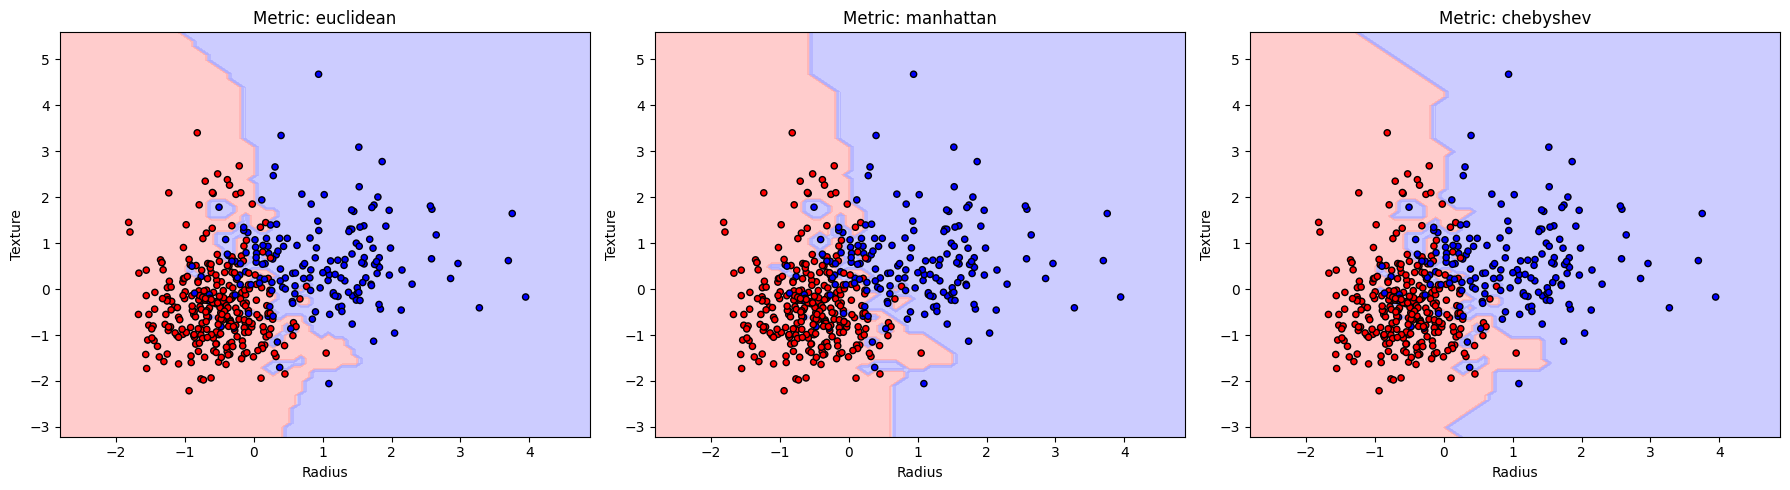

In [38]:
X_train_2d = X_train_scaled[:, :2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, m in enumerate(metrics):
    clf_2d = KNN_Metric(k=best_k, metric=m)
    clf_2d.fit(X_train_2d, y_train)
    
    plot_decision_boundary(axes[i], clf_2d, X_train_2d, y_train, f"Metric: {m}", h=0.1)

plt.tight_layout()
plt.show()